# 6.1 Regression Kriging with scikit-Learn



**Dataset:** Great Plains soil survey (`data/gp_data_5000.csv`, `data/gp_grid.csv`)

**Target:** Soil Organic Carbon (SOC, %)

**Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, **NLCD (categorical)**

**Library:** `pygstat` v0.1.0 — `RegressionKriging`, `ENSEMBLE_REGRESSORS`, `STATISTICAL_REGRESSORS`, `GAMRegressor`, `enforce_quantile_monotonicity`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
   - 3.1 [CPU and GPU](#31-cpu-and-gpu)
4. [Load and Explore the Great Plains Data](#4-load-and-explore-the-great-plains-data)
5. [Prepare Features](#5-prepare-features)
6. [Stratified Train / Test Split](#6-stratified-train--test-split)
7. [Exploratory Variogram of SOC](#7-exploratory-variogram-of-soc)
8. [Fit All Regression-Kriging Models](#8-fit-all-regression-kriging-models)
9. [Cross-Validation and Hold-Out Comparison](#9-cross-validation-and-hold-out-comparison)
10. [Feature Importance](#10-feature-importance)
11. [Quantile Regression Kriging and Monotonicity](#11-quantile-regression-kriging-and-monotonicity)
12. [Predict SOC on Grid Locations](#12-predict-soc-on-grid-locations)
13. [Map Predictions](#13-map-predictions)
14. [CPU vs GPU RK Timing](#14-cpu-vs-gpu-rk-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)


***
## 1. Overview

**Regression Kriging (RK)** is a **geostatistical interpolation method** that combines **deterministic regression modeling** with **stochastic kriging of residuals** to produce spatially optimal predictions.

It is also known as **Universal Kriging** when the regression model is linear in coordinates, but in modern usage RK typically refers to using **external covariates** (e.g., elevation, NDVI, land cover) in the regression step.

In geostatistics, **Simple Kriging with a Varying Local Mean (SKVLM)** and Regression Kriging (RK) refer to the exact same underlying predictive model. The two terms exist because they emerged from different conceptual perspectives:

- **Simple Kriging with a Varying Local Mean** is popularized in the geostatistical school of thought (e.g., Pierre Goovaerts). It treats the process as simple kriging where the global mean ($\mu$) is replaced by a known, spatially varying local trend $m(\mathbf{s})$.
- **Regression Kriging** is widely used in soil science and environmental mapping (e.g., Tomislav Hengl). It treats the process as a two-step framework: first fitting a separate regression model to predict the trend, then using kriging to interpolate the remaining residuals.

RK involves three main steps:

1. **Regression component.** A trend model captures the relationship between the target (here, SOC) and explanatory variables (NDVI, climate, terrain, soils, land cover). This is the **deterministic** part of the spatial variation.
2. **Kriging component.** Residuals (observed minus regression-predicted) are interpolated with ordinary kriging, using a variogram of how those residuals vary with distance. This is the **stochastic** (spatially autocorrelated) part.
3. **Combination.** The prediction at location $\mathbf{s}$ is

$$
Z(\mathbf{s}) = \hat{m}(\mathbf{s}) + \hat{e}(\mathbf{s})
$$

where $\hat{m}(\mathbf{s})$ is the regression trend and $\hat{e}(\mathbf{s})$ is the kriged residual.

`pygstat.RegressionKriging` accepts any scikit-learn-compatible estimator, plus string shortcuts grouped as **`ENSEMBLE_REGRESSORS`** and **`STATISTICAL_REGRESSORS`**.


### Ensemble trend models (`ENSEMBLE_REGRESSORS`)

| Shortcut | Estimator | What it does |
|----------|-----------|--------------|
| `'linear'` | `LinearRegression` | Ordinary least squares. The original RK default: a global linear trend in the covariates. Fast and interpretable; misses nonlinear effects. |
| `'random_forest'` | `RandomForestRegressor` | Averages many de-correlated trees (bagging + random feature subsets). Robust, hard to overfit badly, little tuning required. Exposes `feature_importances_`. |
| `'gradient_boosting'` | `GradientBoostingRegressor` | Builds trees sequentially; each tree corrects the previous ensemble's residual error. Often the most accurate on tabular data, but more sensitive to `learning_rate` / `n_estimators`. |
| `'bagging'` | `BaggingRegressor` | Averages the same base learner (a decision tree by default) trained on bootstrap resamples. The simplest variance-reduction ensemble. |
| `'stacking'` | `StackingRegressor` | Trains several diverse base learners (random forest + gradient boosting + linear, by default) and a ridge meta-learner that combines their out-of-fold predictions. |

### Statistical trend models (`STATISTICAL_REGRESSORS`)

| Shortcut | Estimator | What it does |
|----------|-----------|--------------|
| `'gam'` | `GAMRegressor` (pyGAM wrapper) | A **generalized additive model**: a smooth, per-feature nonlinear trend $\sum_j s_j(X_j)$ that stays interpretable feature-by-feature, unlike a black-box ensemble. Requires the optional `pygam` package (`pip install pygam` or `pip install pygstat[gam]`). |
| `'glm'` | `TweedieRegressor` | A **generalized linear model** (exponential-family noise + link). Default is Gaussian (`power=0`); set `regressor_kwargs={"power": 1}` for Poisson-like, `{"power": 2}` for Gamma — useful for non-negative, skewed targets. |
| `'bayesian_ridge'` | `BayesianRidge` | A linear model with a Gaussian prior on the coefficients; regularization is learned from the data (no `alpha` to tune by hand). `rk.regressor.predict(X, return_std=True)` also returns the regression model's own predictive uncertainty. |
| `'quantile'` | `QuantileRegressor` | Models a chosen **quantile** of the target (median, `quantile=0.5`, by default) rather than its mean. Set `regressor_kwargs={"quantile": 0.9}` for an upper-bound risk surface. |

Pass an already-constructed estimator for full control, or override any shortcut with `regressor_kwargs` (e.g. `RegressionKriging(regressor="random_forest", regressor_kwargs={"n_estimators": 500})`).

### Quantile crossing (`enforce_quantile_monotonicity`)

Independently fitted quantile models (e.g. P10, P50, P90) are **not** guaranteed to stay ordered at every location — a well-known issue called **quantile crossing** (Bassett & Koenker, 1982). Kriging each quantile's own residuals can make crossing worse, because each residual field has a different spatial pattern. `enforce_quantile_monotonicity` applies the rearrangement of Chernozhukov, Fernández-Val & Galichon (2010): sort the predicted quantiles point-by-point so a lower quantile is never above a higher one.

### This tutorial

We map **soil organic carbon (SOC)** across the US Great Plains using **5,000** samples and a ~10 km prediction grid. **NLCD** land-cover class is treated as a **categorical** variable and **one-hot encoded** (scikit-learn's linear, GLM, GAM, and tree estimators do not have H2O-style native factors). Every shortcut in `AVAILABLE_REGRESSORS` is fitted as a regression-kriging model, scored with **5-fold cross-validation** on the training set and a **held-out 30% test set**, then used to **predict SOC at grid locations**. Section 14 times residual **ordinary kriging** on **CPU vs GPU** for prefixes of `data/gp_data_5000.csv`.


***
## 2. Mathematical Formulation

The target variable $Z(\mathbf{s})$ at location $\mathbf{s}$ is modeled as:

$$
Z(\mathbf{s}) = \mu(\mathbf{s}) + \varepsilon(\mathbf{s})
$$

where $\mu(\mathbf{s})$ is the **deterministic trend** (explained by covariates) and $\varepsilon(\mathbf{s})$ is a **spatially autocorrelated residual** (zero-mean, stationary).

### Fit a regression model

Use covariates $\mathbf{X} = [x_1, x_2, \ldots, x_p]$ (e.g. elevation, NDVI) to model the trend. For a linear trend:

$$
\hat{\mu}(\mathbf{s}_i) = \hat{\beta}_0 + \hat{\beta}_1 x_{i1} + \cdots + \hat{\beta}_p x_{ip} = \mathbf{x}_i^T \hat{\boldsymbol{\beta}},
\qquad
\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{z}
$$

Ensembles, GAMs, and other statistical models replace this closed form with a fitted $\hat{\mu}(\mathbf{s}) = f(\mathbf{x})$.

### Compute residuals

$$
e_i = z_i - \hat{\mu}(\mathbf{s}_i), \quad i = 1, \ldots, n
$$

These residuals should be **zero-mean** and **spatially correlated**.

### Model spatial structure of residuals

Fit a **variogram** $\gamma(h)$ to the residuals:

$$
\hat{\gamma}(h) = \frac{1}{2|N(h)|} \sum_{(i,j) \in N(h)} (e_i - e_j)^2
$$

A spherical model is:

$$
\gamma(h) =
\begin{cases}
c_0 + c \left(1.5 \frac{h}{a} - 0.5 \left(\frac{h}{a}\right)^3 \right), & h < a \\
c_0 + c, & h \geq a
\end{cases}
$$

where $c_0$ is the nugget, $c$ the partial sill, and $a$ the range.

### Kriging on residuals

At an unsampled location $\mathbf{s}_0$, predict the residual with **ordinary kriging**:

$$
\hat{\varepsilon}(\mathbf{s}_0) = \sum_{i=1}^n \lambda_i e_i
$$

The weights $\lambda_i$ solve:

$$
\begin{bmatrix}
\mathbf{C} & \mathbf{1} \\
\mathbf{1}^T & 0
\end{bmatrix}
\begin{bmatrix}
\boldsymbol{\lambda} \\
\mu
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{c} \\
1
\end{bmatrix}
$$

where $\mathbf{C}_{ij} = C(\|\mathbf{s}_i - \mathbf{s}_j\|) = C(0) - \gamma(\|\mathbf{s}_i - \mathbf{s}_j\|)$, $\mathbf{c}_i = C(\|\mathbf{s}_i - \mathbf{s}_0\|)$, and $C(0) = c_0 + c$.

### Final prediction and uncertainty

$$
\hat{Z}(\mathbf{s}_0) = \hat{\mu}(\mathbf{s}_0) + \hat{\varepsilon}(\mathbf{s}_0)
$$

Kriging variance:

$$
\sigma_K^2(\mathbf{s}_0) = C(0) - \boldsymbol{\lambda}^T \mathbf{c} - \mu
$$

### Why use regression kriging?

| Method | Pros | Cons |
|--------|------|------|
| **Ordinary kriging** | Simple; only needs coordinates | Cannot use covariates |
| **Regression only** | Fast, interpretable | Ignores spatial autocorrelation |
| **Regression kriging** | Uses covariates **and** models spatial residuals | More moving parts |

### Real-world example: soil organic carbon

- **Covariates:** NDVI (vegetation), elevation, MAP (rainfall), land cover, soils, climate
- **Trend:** SOC tends to increase with NDVI and MAP
- **Residuals:** spatial clustering from unmeasured factors (soil type, management)
- **RK:** captures both the **global trend** and **local spatial structure**


***
## 3. Python Setup

### 3.1 CPU and GPU

`RegressionKriging` fits the scikit-learn trend on **CPU**, then builds the residual covariance and solves the **ordinary kriging** system on **CPU** (NumPy/SciPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. Every `RegressionKriging(...)` call below passes `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

The **linear-algebra** steps that move to the GPU are the $n \times n$ residual covariance, the $n_{\text{pred}} \times n$ covariance to the targets, and the augmented OK solve. The sklearn trend itself always stays on CPU.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 14 times residual OK (`RegressionKriging` with `regressor='linear'`) on both backends using prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline

import os
import sys
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
sys.path.insert(0, os.path.abspath("../src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

import pygstat
from pygstat import (
    AVAILABLE_REGRESSORS,
    ENSEMBLE_REGRESSORS,
    GAMRegressor,
    KFoldCV_RK,
    RegressionKriging,
    STATISTICAL_REGRESSORS,
    Variogram,
    enforce_quantile_monotonicity,
)
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")
print("ENSEMBLE_REGRESSORS   :", ENSEMBLE_REGRESSORS)
print("STATISTICAL_REGRESSORS:", STATISTICAL_REGRESSORS)
print("AVAILABLE_REGRESSORS  :", AVAILABLE_REGRESSORS)
print("GAMRegressor          :", GAMRegressor)
print("enforce_quantile_monotonicity:", enforce_quantile_monotonicity.__name__)

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — residual OK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


pygstat version : 0.1.0
NumPy           : 2.2.6
pandas          : 2.3.3
ENSEMBLE_REGRESSORS   : ('linear', 'random_forest', 'gradient_boosting', 'bagging', 'stacking')
STATISTICAL_REGRESSORS: ('gam', 'glm', 'bayesian_ridge', 'quantile')
AVAILABLE_REGRESSORS  : ('linear', 'random_forest', 'gradient_boosting', 'bagging', 'stacking', 'gam', 'glm', 'bayesian_ridge', 'quantile')
GAMRegressor          : <class 'pygstat.regression_kriging.GAMRegressor'>
enforce_quantile_monotonicity: enforce_quantile_monotonicity
CuPy            : 14.2.0
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — residual OK covariance + solve on GPU
use_gpu         : True


***
## 4. Load and Explore the Great Plains Data

Point samples live in `data/gp_data_5000.csv` (SOC plus covariates at 5,000 locations). The prediction grid is `data/gp_grid.csv` (covariates only). Coordinates are US Albers Equal Area (EPSG:5070), in metres.

The CSV header repeats `NLCD`; pandas renames the second copy to `NLCD.1`. That extra column is dropped. The first `NLCD` column matches the grid (classes 3–7) and is kept as a **categorical** land-cover code.


In [2]:
DATA_DIR = Path("..") / "data"
df = pd.read_csv(DATA_DIR / "gp_data_5000.csv")
grid_df = pd.read_csv(DATA_DIR / "gp_grid.csv")
df = df.drop(columns=["NLCD.1"], errors="ignore")

print(f"Samples: {len(df):,}  |  Grid nodes: {len(grid_df):,}")
print("Sample columns:", list(df.columns))
print("Grid columns  :", list(grid_df.columns))
df.head()


Samples: 5,000  |  Grid nodes: 10,674
Sample columns: ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI', 'SOC']
Grid columns  : ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI']


,x,y,Aspect,ELEV,FRG,K_Factor,MAP,MAT,NDVI,NLCD,Silt_Clay,Slope,TPI,SOC
0,-955285,1723795,190.939880,3253.481445,3,0.215152,509.138000,1.762475,0.555731,4,43.668686,16.048429,-10.495800,7.542836
1,-735285,1973795,151.478363,1464.635742,2,0.212500,346.081512,9.494437,0.598498,7,48.345001,1.105268,-0.606075,6.102204
2,-975285,1103795,129.981384,1441.645264,133,0.112800,372.746063,15.771700,0.239591,5,38.459999,12.090247,2.133632,3.611722
3,-395285,1883795,143.175690,841.138855,2,0.320000,548.891235,10.720102,0.483404,6,87.089798,2.587129,-0.656106,7.510275
4,-925285,1173795,224.581604,1490.575562,3,0.283511,357.764221,14.428139,0.215801,5,53.868084,6.122041,0.595470,2.377830


In [3]:
print(df[["SOC", "NDVI", "MAP", "MAT", "ELEV", "Silt_Clay"]].describe().round(2))

NLCD_DES = {
    3: "Barren / other",
    4: "Forest",
    5: "Shrubland",
    6: "Herbaceous",
    7: "Planted/Cultivated",
}
print("\nNLCD classes (samples):")
print(
    df.groupby("NLCD").size().rename("n").to_frame()
    .assign(description=lambda s: s.index.map(NLCD_DES))
)
print("\nMean SOC by NLCD class:")
print(
    df.groupby("NLCD")["SOC"].mean().rename("mean_SOC").to_frame()
    .assign(description=lambda s: s.index.map(NLCD_DES))
    .round(2)
)


           SOC     NDVI      MAP      MAT     ELEV  Silt_Clay
count  5000.00  5000.00  5000.00  5000.00  5000.00    5000.00
mean      6.03     0.41   488.67     9.10  1657.04      53.89
std       3.70     0.16   213.48     4.18   743.29      16.41
min       0.03     0.05   153.58    -2.52   234.55       1.75
25%       3.24     0.27   345.48     6.29  1207.24      42.36
50%       5.12     0.38   424.78     9.57  1656.71      52.61
75%       8.03     0.53   585.63    12.42  2175.49      62.70
max      23.75     0.82  1749.11    17.88  3688.66      90.74

NLCD classes (samples):
         n         description
NLCD                          
3       19      Barren / other
4      956              Forest
5     1657           Shrubland
6     1519          Herbaceous
7      849  Planted/Cultivated

Mean SOC by NLCD class:
      mean_SOC         description
NLCD                              
3         5.64      Barren / other
4         9.56              Forest
5         3.94           Shrubland


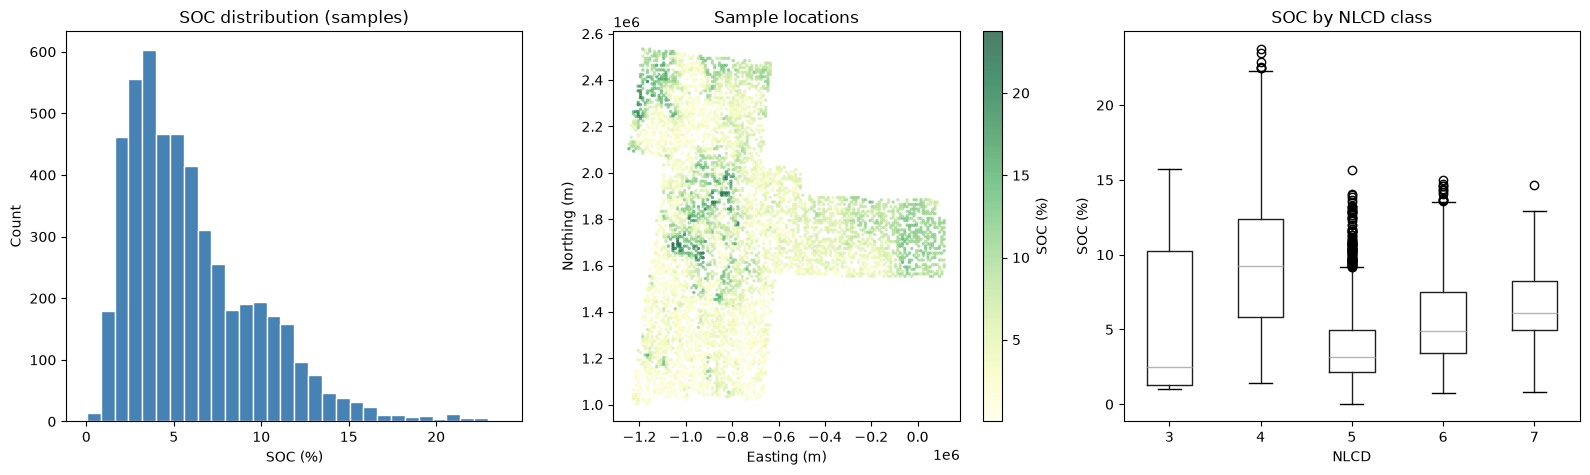

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(df["SOC"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("SOC (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("SOC distribution (samples)")

sc = axes[1].scatter(df["x"], df["y"], c=df["SOC"], s=6, cmap="YlGn", edgecolors="none", alpha=0.7)
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].set_title("Sample locations")
axes[1].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[1], label="SOC (%)")

df.boxplot(column="SOC", by="NLCD", ax=axes[2], grid=False)
axes[2].set_title("SOC by NLCD class")
axes[2].set_xlabel("NLCD")
axes[2].set_ylabel("SOC (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()


***
## 5. Prepare Features

**NLCD is a categorical land-cover class**, not a numeric intensity. Recoding it to an ordinal score would impose a false order (forest is not “more NLCD” than shrubland). scikit-learn’s linear models, GLM, quantile regression, GAM, and tree ensembles all see a numeric matrix, so NLCD is **one-hot encoded**:

- `OneHotEncoder(drop="first")` creates dummy columns and drops the first class as the baseline (avoids the dummy trap in linear / GLM / Bayesian ridge / quantile models).
- The same dummy columns are passed to tree ensembles and the GAM so every trend model uses the same feature matrix.
- The encoder is fit on the sample table and applied to the prediction grid (`handle_unknown="ignore"`).


In [5]:
required_cols = [
    "x", "y", "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay", "NLCD",
]
for col in required_cols:
    if col not in df.columns or col not in grid_df.columns:
        raise ValueError(f"Missing column: {col}")

numeric_cols = [
    "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay",
]
cat_cols = ["NLCD"]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
    dtype=float,
)
encoder.fit(df[cat_cols])
nlcd_dummy_names = encoder.get_feature_names_out(cat_cols).tolist()
encoded_feature_names = numeric_cols + nlcd_dummy_names
baseline = encoder.categories_[0][0]


def encode_X(frame):
    num = frame[numeric_cols].to_numpy(dtype=float)
    cat = encoder.transform(frame[cat_cols])
    return np.hstack([num, cat])


X = encode_X(df)
y = df["SOC"].to_numpy(dtype=float)
coords = df[["x", "y"]].to_numpy(dtype=float)
X_grid = encode_X(grid_df)
coords_grid = grid_df[["x", "y"]].to_numpy(dtype=float)

print("Numeric features:", numeric_cols)
print("NLCD categories :", list(encoder.categories_[0]))
print(f"Dropped baseline: {int(baseline)} ({NLCD_DES.get(int(baseline), '?')})")
print("Dummy columns   :", nlcd_dummy_names)
print("Encoded features:", encoded_feature_names)
print("X:", X.shape, "  y:", y.shape, "  coords:", coords.shape)
print("Grid X:", X_grid.shape)


Numeric features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay']
NLCD categories : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Dropped baseline: 3 (Barren / other)
Dummy columns   : ['NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
Encoded features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay', 'NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
X: (5000, 13)   y: (5000,)   coords: (5000, 2)
Grid X: (10674, 13)


***
## 6. Stratified Train / Test Split

A 70% / 30% split, stratified by **NLCD class** so each land-cover category is represented in both sets (`random_state=42`).


In [6]:
nlcd_labels = df["NLCD"].to_numpy()
counts = Counter(nlcd_labels)
stratify_arg = nlcd_labels if min(counts.values()) >= 2 else None

X_train, X_test, y_train, y_test, coords_train, coords_test, nlcd_train, nlcd_test = train_test_split(
    X, y, coords, nlcd_labels,
    test_size=0.3,
    random_state=42,
    shuffle=True,
    stratify=stratify_arg,
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print("NLCD distribution in train set:", sorted(Counter(nlcd_train).items()))
print("NLCD distribution in test set: ", sorted(Counter(nlcd_test).items()))


Training samples: 3500, Test samples: 1500
NLCD distribution in train set: [(np.int64(3), 13), (np.int64(4), 669), (np.int64(5), 1160), (np.int64(6), 1063), (np.int64(7), 595)]
NLCD distribution in test set:  [(np.int64(3), 6), (np.int64(4), 287), (np.int64(5), 497), (np.int64(6), 456), (np.int64(7), 254)]


***
## 7. Exploratory Variogram of SOC

Before residual kriging, look at the **raw SOC** variogram. Lag count uses Scott's rule on a random subset of pairwise distances, capped at 30 lags: bin width $h = 3.5 \, \mathrm{std}\,/\, n^{1/3}$.


In [7]:
# Scott's rule on a random subset keeps the n=5,000 distance matrix light
rng = np.random.default_rng(42)
idx = rng.choice(len(coords), size=min(1200, len(coords)), replace=False)
sample_xy = coords[idx]
distances = np.sqrt(((sample_xy[:, None, :] - sample_xy[None, :, :]) ** 2).sum(axis=2))
upper_triangle = distances[np.triu_indices_from(distances, k=1)]
std_dist = np.nanstd(upper_triangle)
n_pairs = len(upper_triangle)
scott_bin_width = 3.5 * std_dist / (n_pairs ** (1 / 3))
maxlag_soc = float(np.nanpercentile(upper_triangle, 50))
n_lags_soc = max(5, min(30, int(maxlag_soc / scott_bin_width)))
print(f"Using Scott rule → n_lags: {n_lags_soc}, maxlag: {maxlag_soc:.1f} m")


Using Scott rule → n_lags: 30, maxlag: 624259.6 m


In [8]:
vg = Variogram(
    coords, y,
    model="spherical",
    estimator="matheron",
    maxlag=maxlag_soc,
    n_lags=n_lags_soc,
    use_gpu="auto",
)
vg.fit()
mask = ~np.isnan(vg.experimental)
rmse_vg = np.sqrt(np.mean((vg.experimental[mask] - vg(vg.lags)[mask]) ** 2))
nugget, psill, rng = vg.fitted_params
print(f"Spherical model RMSE: {rmse_vg:.2f}")
print(f"nugget={nugget:.3f}, partial sill={psill:.3f}, range={rng:.1f} m")


Spherical model RMSE: 0.48
nugget=3.369, partial sill=10.431, range=312129.8 m


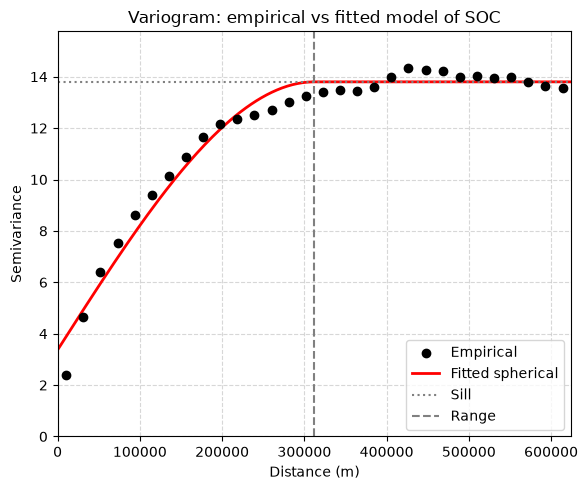

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(vg.lags, vg.experimental, color="black", label="Empirical", zorder=3)
h_fine = np.linspace(0, vg.maxlag, 200)
plt.plot(h_fine, vg(h_fine), color="red", linewidth=2, label="Fitted spherical")
plt.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
plt.axvline(rng, color="gray", linestyle="--", label="Range")
plt.xlabel("Distance (m)")
plt.ylabel("Semivariance")
plt.title("Variogram: empirical vs fitted model of SOC")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, vg.maxlag)
plt.ylim(0, np.nanmax(vg.experimental) * 1.1)
plt.tight_layout()
plt.show()


Residual variograms (next section) typically have a **shorter range** than the raw SOC variogram, because the regression has already absorbed the large-scale trend. We therefore use a shorter `maxlag` (50 km, 15 lags) when auto-fitting the residual models — the same setting as the original tutorial.


***
## 8. Fit All Regression-Kriging Models

Each shortcut in `AVAILABLE_REGRESSORS` is built with `RegressionKriging(regressor=...)`. Tree ensembles use a modest `n_estimators` so the notebook stays interactive; stacking uses a slightly lighter set of base learners than the library default. `GAMRegressor` is the `'gam'` shortcut (shown explicitly below). Hyperparameters can always be overridden with `regressor_kwargs`.


In [10]:
try:
    import pygam  # noqa: F401
    HAS_GAM = True
except ImportError:
    HAS_GAM = False
    print("pygam is not installed — skipping regressor='gam'. Install with: pip install pygam")

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

VARIOGRAM_KWARGS = {"maxlag": 50_000, "n_lags": 15}

REGRESSOR_KWARGS = {
    "linear": {},
    "random_forest": {"n_estimators": 200, "max_depth": 10, "random_state": 42, "n_jobs": -1},
    "gradient_boosting": {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "random_state": 42},
    "bagging": {"n_estimators": 50, "random_state": 42},
    "stacking": {
        "estimators": [
            ("random_forest", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
            ("gradient_boosting", GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)),
            ("linear", LinearRegression()),
        ],
        "final_estimator": RidgeCV(),
    },
    "gam": {"n_splines": 8, "lam": 0.6},
    "glm": {},
    "bayesian_ridge": {},
    "quantile": {"quantile": 0.5, "solver": "highs"},
}

FAMILY = {name: "ensemble" for name in ENSEMBLE_REGRESSORS}
FAMILY.update({name: "statistical" for name in STATISTICAL_REGRESSORS})

model_names = [n for n in AVAILABLE_REGRESSORS if n != "gam" or HAS_GAM]
fitted = {}

for name in model_names:
    print(f"Fitting RK with regressor='{name}' ({FAMILY[name]}) ...")
    rk = RegressionKriging(
        regressor=name,
        regressor_kwargs=REGRESSOR_KWARGS.get(name, {}),
        kriging_type="ordinary",
        variogram_model="spherical",
        variogram_kwargs=VARIOGRAM_KWARGS,
        use_gpu=USE_GPU,
    )
    rk.fit(X_train, y_train, coords_train)
    params = rk.variogram_.fitted_params
    print(
        f"  {type(rk.regressor).__name__}: "
        f"nugget={params[0]:.3f}, sill={params[1]:.3f}, range={params[2]:.1f} m"
    )
    fitted[name] = rk

print(f"\nFitted {len(fitted)} RK models.")
print("Example GAMRegressor instance:", GAMRegressor(n_splines=8, lam=0.6))


Fitting RK with regressor='linear' (ensemble) ...


  LinearRegression: nugget=0.682, sill=1.753, range=46455.3 m
Fitting RK with regressor='random_forest' (ensemble) ...


  RandomForestRegressor: nugget=0.093, sill=0.193, range=25000.0 m
Fitting RK with regressor='gradient_boosting' (ensemble) ...


  GradientBoostingRegressor: nugget=0.116, sill=0.528, range=25000.0 m
Fitting RK with regressor='bagging' (ensemble) ...


  BaggingRegressor: nugget=0.042, sill=0.088, range=25000.0 m
Fitting RK with regressor='stacking' (ensemble) ...


  StackingRegressor: nugget=0.107, sill=0.201, range=25000.0 m
Fitting RK with regressor='gam' (statistical) ...


  GAMRegressor: nugget=0.584, sill=0.982, range=46695.8 m
Fitting RK with regressor='glm' (statistical) ...


  TweedieRegressor: nugget=0.695, sill=2.194, range=42931.5 m
Fitting RK with regressor='bayesian_ridge' (statistical) ...


  BayesianRidge: nugget=0.682, sill=1.751, range=46412.1 m
Fitting RK with regressor='quantile' (statistical) ...


  QuantileRegressor: nugget=0.658, sill=1.851, range=47135.8 m

Fitted 9 RK models.
Example GAMRegressor instance: GAMRegressor(distribution='normal', link='identity', n_splines=8, lam=0.6)


***
## 9. Cross-Validation and Hold-Out Comparison

For every fitted model we report:

- **5-fold CV** on the training set (`KFoldCV_RK`) — each fold refits both the trend and the residual kriging
- **Hold-out test** metrics on the 30% test set (model fitted on the full training set)

Leave-one-out CV (`LOOCV_RK`) is available in pygstat but is omitted here: repeating stacking / gradient boosting hundreds of times is slow, and 5-fold CV already ranks the models.


In [11]:
kfold_cv = KFoldCV_RK(n_splits=5, random_state=42)
rows = []

for name, rk in fitted.items():
    cv = kfold_cv.validate(rk, X_train, y_train, coords_train)
    y_hat = rk.predict(X_test, coords_test)
    rows.append({
        "regressor": name,
        "family": FAMILY[name],
        "estimator": type(rk.regressor).__name__,
        "cv_rmse": cv["rmse"],
        "cv_r2": cv["r2"],
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_hat))),
        "test_mae": float(mean_absolute_error(y_test, y_hat)),
        "test_r2": float(r2_score(y_test, y_hat)),
        "y_pred_test": y_hat,
    })
    print(
        f"{name:20s}  CV RMSE={cv['rmse']:.3f}  R²={cv['r2']:.3f}  |  "
        f"Test RMSE={rows[-1]['test_rmse']:.3f}  MAE={rows[-1]['test_mae']:.3f}  R²={rows[-1]['test_r2']:.3f}"
    )

results = pd.DataFrame(rows).drop(columns=["y_pred_test"])
results = results.sort_values("test_rmse").reset_index(drop=True)
best_name = results.loc[0, "regressor"]
best_rk = fitted[best_name]
print(f"\nBest hold-out RMSE: {best_name}  ({type(best_rk.regressor).__name__})")
results.round(3)


linear                CV RMSE=1.279  R²=0.878  |  Test RMSE=1.216  MAE=0.822  R²=0.896


random_forest         CV RMSE=0.974  R²=0.929  |  Test RMSE=0.876  MAE=0.607  R²=0.946


gradient_boosting     CV RMSE=0.954  R²=0.932  |  Test RMSE=0.881  MAE=0.613  R²=0.946


bagging               CV RMSE=0.974  R²=0.929  |  Test RMSE=0.881  MAE=0.605  R²=0.946


stacking              CV RMSE=0.959  R²=0.932  |  Test RMSE=0.870  MAE=0.604  R²=0.947


gam                   CV RMSE=1.090  R²=0.912  |  Test RMSE=1.027  MAE=0.734  R²=0.926


glm                   CV RMSE=1.434  R²=0.847  |  Test RMSE=1.348  MAE=0.893  R²=0.873


bayesian_ridge        CV RMSE=1.279  R²=0.878  |  Test RMSE=1.216  MAE=0.821  R²=0.896


quantile              CV RMSE=1.271  R²=0.880  |  Test RMSE=1.216  MAE=0.814  R²=0.897

Best hold-out RMSE: stacking  (StackingRegressor)


,regressor,family,estimator,cv_rmse,cv_r2,test_rmse,test_mae,test_r2
0,stacking,ensemble,StackingRegressor,0.959,0.932,0.870,0.604,0.947
1,random_forest,ensemble,RandomForestRegressor,0.974,0.929,0.876,0.607,0.946
2,gradient_boosting,ensemble,GradientBoostingRegressor,0.954,0.932,0.881,0.613,0.946
3,bagging,ensemble,BaggingRegressor,0.974,0.929,0.881,0.605,0.946
4,gam,statistical,GAMRegressor,1.090,0.912,1.027,0.734,0.926
5,quantile,statistical,QuantileRegressor,1.271,0.880,1.216,0.814,0.897
6,linear,ensemble,LinearRegression,1.279,0.878,1.216,0.822,0.896
7,bayesian_ridge,statistical,BayesianRidge,1.279,0.878,1.216,0.821,0.896
8,glm,statistical,TweedieRegressor,1.434,0.847,1.348,0.893,0.873


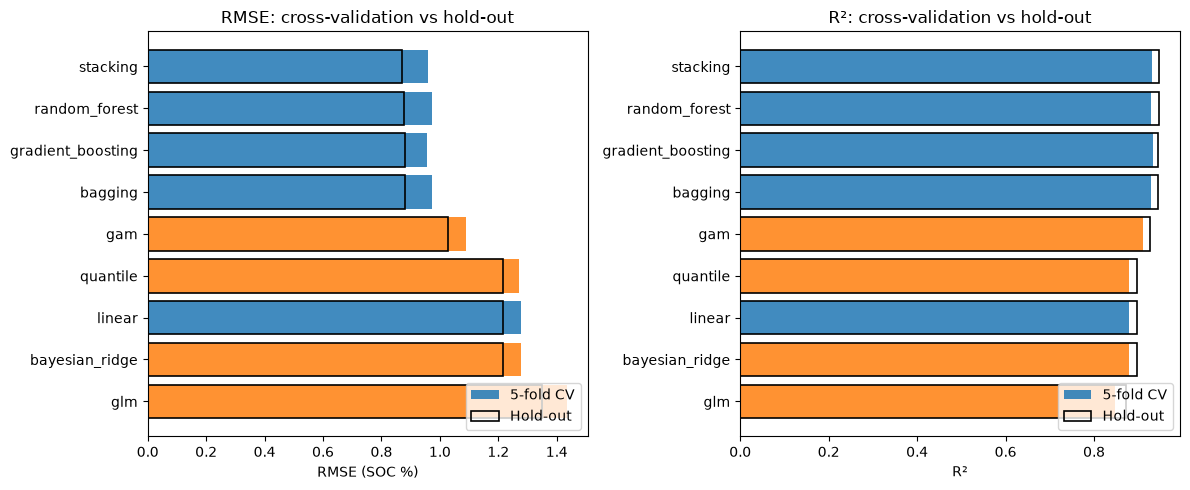

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = results.sort_values("test_rmse")
colors = ["C0" if f == "ensemble" else "C1" for f in order["family"]]
axes[0].barh(order["regressor"], order["cv_rmse"], color=colors, alpha=0.85, label="5-fold CV")
axes[0].barh(order["regressor"], order["test_rmse"], color="none", edgecolor="black", linewidth=1.2, label="Hold-out")
axes[0].set_xlabel("RMSE (SOC %)")
axes[0].set_title("RMSE: cross-validation vs hold-out")
axes[0].legend(loc="lower right")
axes[0].invert_yaxis()

axes[1].barh(order["regressor"], order["cv_r2"], color=colors, alpha=0.85, label="5-fold CV")
axes[1].barh(order["regressor"], order["test_r2"], color="none", edgecolor="black", linewidth=1.2, label="Hold-out")
axes[1].set_xlabel("R²")
axes[1].set_title("R²: cross-validation vs hold-out")
axes[1].legend(loc="lower right")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### Observed vs predicted on the test set

One-to-one plots for the best model and a few representative alternatives (linear baseline, a tree ensemble, and a statistical model).


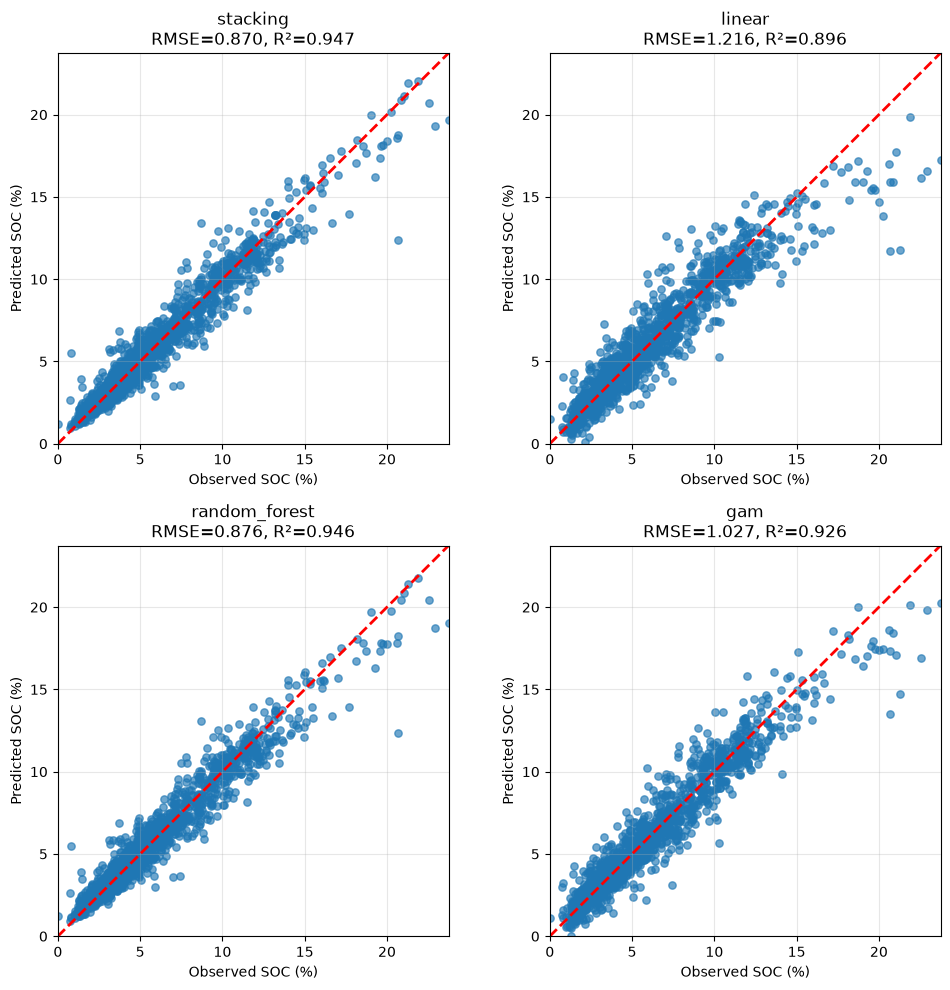

In [13]:
show = [best_name]
for extra in ("linear", "random_forest", "gam", "quantile"):
    if extra in fitted and extra not in show:
        show.append(extra)
show = show[:4]

pred_lookup = {row["regressor"]: row for row in rows}
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
lims = [min(y_test.min(), min(pred_lookup[n]["y_pred_test"].min() for n in show)),
        max(y_test.max(), max(pred_lookup[n]["y_pred_test"].max() for n in show))]

for ax, name in zip(axes.ravel(), show):
    y_hat = pred_lookup[name]["y_pred_test"]
    ax.scatter(y_test, y_hat, alpha=0.65, s=28)
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Observed SOC (%)")
    ax.set_ylabel("Predicted SOC (%)")
    rec = results.set_index("regressor").loc[name]
    ax.set_title(f"{name}\nRMSE={rec['test_rmse']:.3f}, R²={rec['test_r2']:.3f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Residual variograms of two trend models

The residual variogram depends on the trend: a more flexible regressor typically leaves **less structured** residual spatial variation (smaller sill / shorter range).


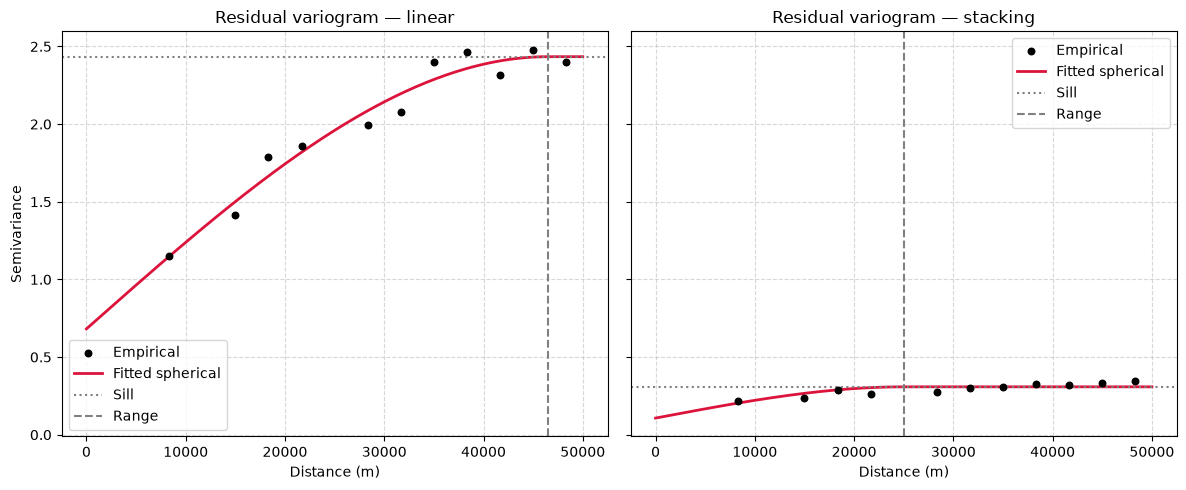

In [14]:
pair = [n for n in ("linear", best_name) if n in fitted]
if len(pair) < 2:
    pair = list(fitted.keys())[:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, pair):
    vg_r = fitted[name].variogram_
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine, vg_r(h_fine), color="crimson", lw=2, label="Fitted spherical")
    nugget_r, psill_r, rng_r = vg_r.fitted_params
    ax.axhline(nugget_r + psill_r, color="gray", ls=":", label="Sill")
    ax.axvline(rng_r, color="gray", ls="--", label="Range")
    ax.set_xlabel("Distance (m)")
    ax.set_title(f"Residual variogram — {name}")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend()
axes[0].set_ylabel("Semivariance")
plt.tight_layout()
plt.show()


***
## 10. Feature Importance

Tree-based ensembles that expose `feature_importances_` (random forest and gradient boosting) can be read through `RegressionKriging.feature_importances_`. Linear models, GAM, GLM, Bayesian ridge, quantile regression, bagging, and most stacking configurations do not.


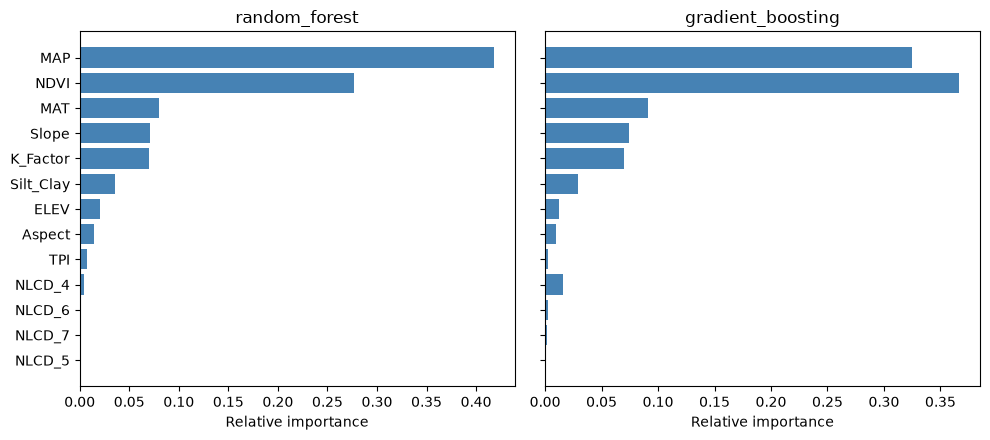

,random_forest,gradient_boosting
NDVI,0.276,0.367
MAP,0.418,0.325
MAT,0.080,0.091
ELEV,0.020,0.012
Slope,0.071,0.074
TPI,0.008,0.003
Aspect,0.014,0.010
K_Factor,0.070,0.070
Silt_Clay,0.036,0.029
NLCD_4,0.005,0.016


In [15]:
tree_names = [
    n for n in ("random_forest", "gradient_boosting", "bagging")
    if n in fitted and hasattr(fitted[n].regressor, "feature_importances_")
]
n_tree = len(tree_names)
fig, axes = plt.subplots(1, n_tree, figsize=(5 * n_tree, 4.5), sharey=True)
if n_tree == 1:
    axes = [axes]

for ax, name in zip(axes, tree_names):
    rk = fitted[name]
    imp = pd.Series(rk.feature_importances_, index=encoded_feature_names).sort_values()
    ax.barh(imp.index, imp.values, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Relative importance")

plt.tight_layout()
plt.show()

imp_table = pd.DataFrame(
    {n: fitted[n].feature_importances_ for n in tree_names},
    index=encoded_feature_names,
)
imp_table.round(3)


***
## 11. Quantile Regression Kriging and Monotonicity

`regressor='quantile'` models a chosen quantile of SOC instead of the mean. Fitting P10, P50, and P90 as **separate** RK models does not keep them ordered — **quantile crossing**. `enforce_quantile_monotonicity` sorts predictions at each location so $q_{0.1} \le q_{0.5} \le q_{0.9}$.


In [16]:
QUANTILES = (0.1, 0.5, 0.9)
quantile_models = {}
q_pred_test = {}

for q in QUANTILES:
    print(f"Fitting quantile RK, q={q} ...")
    rk_q = RegressionKriging(
        regressor="quantile",
        regressor_kwargs={"quantile": q, "solver": "highs"},
        variogram_model="spherical",
        variogram_kwargs=VARIOGRAM_KWARGS,
        use_gpu=USE_GPU,
    )
    rk_q.fit(X_train, y_train, coords_train)
    quantile_models[q] = rk_q
    q_pred_test[q] = rk_q.predict(X_test, coords_test)

raw_ok = (q_pred_test[0.1] <= q_pred_test[0.5] + 1e-9) & (q_pred_test[0.5] <= q_pred_test[0.9] + 1e-9)
print(f"\nTest locations with ordered raw quantiles: {raw_ok.mean():.1%}")

q_fixed_test = enforce_quantile_monotonicity(q_pred_test)
fixed_ok = (q_fixed_test[0.1] <= q_fixed_test[0.5] + 1e-9) & (q_fixed_test[0.5] <= q_fixed_test[0.9] + 1e-9)
print(f"After enforce_quantile_monotonicity:     {fixed_ok.mean():.1%}")

q_table = pd.DataFrame({
    "observed": y_test,
    "P10_raw": q_pred_test[0.1],
    "P50_raw": q_pred_test[0.5],
    "P90_raw": q_pred_test[0.9],
    "P10": q_fixed_test[0.1],
    "P50": q_fixed_test[0.5],
    "P90": q_fixed_test[0.9],
})
q_table.head()


Fitting quantile RK, q=0.1 ...


Fitting quantile RK, q=0.5 ...


Fitting quantile RK, q=0.9 ...



Test locations with ordered raw quantiles: 33.4%
After enforce_quantile_monotonicity:     100.0%


,observed,P10_raw,P50_raw,P90_raw,P10,P50,P90
0,2.392711,2.759605,2.483288,2.198420,2.198420,2.483288,2.759605
1,2.785641,2.554055,2.266115,2.040440,2.040440,2.266115,2.554055
2,3.093102,3.468992,3.199859,3.159738,3.159738,3.199859,3.468992
3,3.813740,4.581357,4.385231,4.222278,4.222278,4.385231,4.581357
4,4.659712,4.581349,4.556155,4.537324,4.537324,4.556155,4.581349


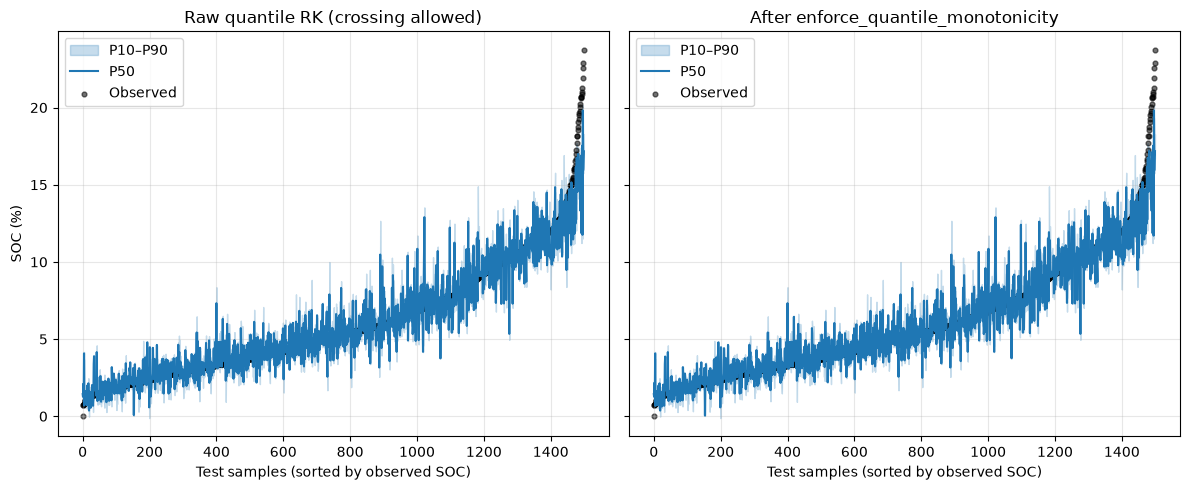

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
idx = np.argsort(y_test)

for ax, preds, title in [
    (axes[0], q_pred_test, "Raw quantile RK (crossing allowed)"),
    (axes[1], q_fixed_test, "After enforce_quantile_monotonicity"),
]:
    ax.fill_between(np.arange(len(idx)), preds[0.1][idx], preds[0.9][idx],
                    color="C0", alpha=0.25, label="P10–P90")
    ax.plot(np.arange(len(idx)), preds[0.5][idx], color="C0", lw=1.5, label="P50")
    ax.scatter(np.arange(len(idx)), y_test[idx], s=12, color="k", alpha=0.55, label="Observed")
    ax.set_xlabel("Test samples (sorted by observed SOC)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("SOC (%)")
plt.tight_layout()
plt.show()


***
## 12. Predict SOC on Grid Locations

Each fitted RK model predicts SOC at the `gp_grid.csv` nodes. We also store the **regression-only** surface and **kriged residuals** for the best model, plus kriging standard error. Quantile P10 / P50 / P90 surfaces are predicted on the same grid and then rearranged with `enforce_quantile_monotonicity`.

For the published map we **refit the best model on all 5,000 samples** (train + test) so no hold-out information is wasted. Validation metrics above still use only the training fit.


In [18]:
print(f"Refitting best model '{best_name}' on all {len(y)} samples ...")
best_full = RegressionKriging(
    regressor=best_name,
    regressor_kwargs=REGRESSOR_KWARGS.get(best_name, {}),
    kriging_type="ordinary",
    variogram_model="spherical",
    variogram_kwargs=VARIOGRAM_KWARGS,
    use_gpu=USE_GPU,
)
best_full.fit(X, y, coords)

print("Predicting SOC on the grid for every trend model ...")
for name, rk in fitted.items():
    grid_df[f"SOC_{name}"] = rk.predict(X_grid, coords_grid)

SOC_pred, SOC_se = best_full.predict(X_grid, coords_grid, return_std=True)
grid_df["SOC_best"] = SOC_pred
grid_df["SOC_best_se"] = SOC_se
grid_df["reg_best"] = best_full.regressor.predict(X_grid)
grid_df["resid_best"] = grid_df["SOC_best"] - grid_df["reg_best"]

print("Predicting quantile surfaces on the grid ...")
q_grid = {}
for q, rk_q in quantile_models.items():
    q_grid[q] = rk_q.predict(X_grid, coords_grid)
q_grid_fixed = enforce_quantile_monotonicity(q_grid)
grid_df["SOC_P10"] = q_grid_fixed[0.1]
grid_df["SOC_P50"] = q_grid_fixed[0.5]
grid_df["SOC_P90"] = q_grid_fixed[0.9]

print(grid_df[["x", "y", "SOC_best", "SOC_best_se", "reg_best", "resid_best", "SOC_P10", "SOC_P50", "SOC_P90"]].describe().round(3))


Refitting best model 'stacking' on all 5000 samples ...


Predicting SOC on the grid for every trend model ...


Predicting quantile surfaces on the grid ...


                 x            y   SOC_best  SOC_best_se   reg_best  \
count    10674.000    10674.000  10674.000    10674.000  10674.000   
mean   -753412.225  1757164.871      6.004        0.269      6.005   
std     327749.190   382369.477      3.642        0.253      3.595   
min   -1245285.000  1003795.000      0.033        0.000      0.910   
25%   -1005285.000  1503795.000      3.248        0.000      3.263   
50%    -825285.000  1743795.000      5.083        0.480      5.042   
75%    -625285.000  2023795.000      7.945        0.507      7.886   
max     114715.000  2533795.000     23.746        0.565     22.828   

       resid_best    SOC_P10    SOC_P50    SOC_P90  
count   10674.000  10674.000  10674.000  10674.000  
mean       -0.001      5.797      5.988      6.182  
std         0.490      3.503      3.516      3.582  
min        -4.970     -1.451     -0.372     -0.209  
25%        -0.238      3.194      3.335      3.473  
50%        -0.013      4.956      5.144      5.308 

In [19]:
out_path = DATA_DIR / "gp_prediction_RK.csv"
grid_df.to_csv(out_path, index=False)
print(f"Grid predictions saved to {out_path}")


Grid predictions saved to ../data/gp_prediction_RK.csv


***
## 13. Map Predictions

Points are plotted in EPSG:5070 with Great Plains state boundaries (`data/GP_STATE.shp`).


In [20]:
states = gpd.read_file(DATA_DIR / "GP_STATE.shp")
gdf_pred = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df.x, grid_df.y),
    crs="EPSG:5070",
)
states = states.to_crs(gdf_pred.crs)


def map_points(ax, column, cmap, title, vmin=None, vmax=None):
    gdf_pred.plot(
        column=column, ax=ax, legend=True, cmap=cmap,
        markersize=4, vmin=vmin, vmax=vmax,
        legend_kwds={"shrink": 0.7},
    )
    states.boundary.plot(ax=ax, color="k", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")


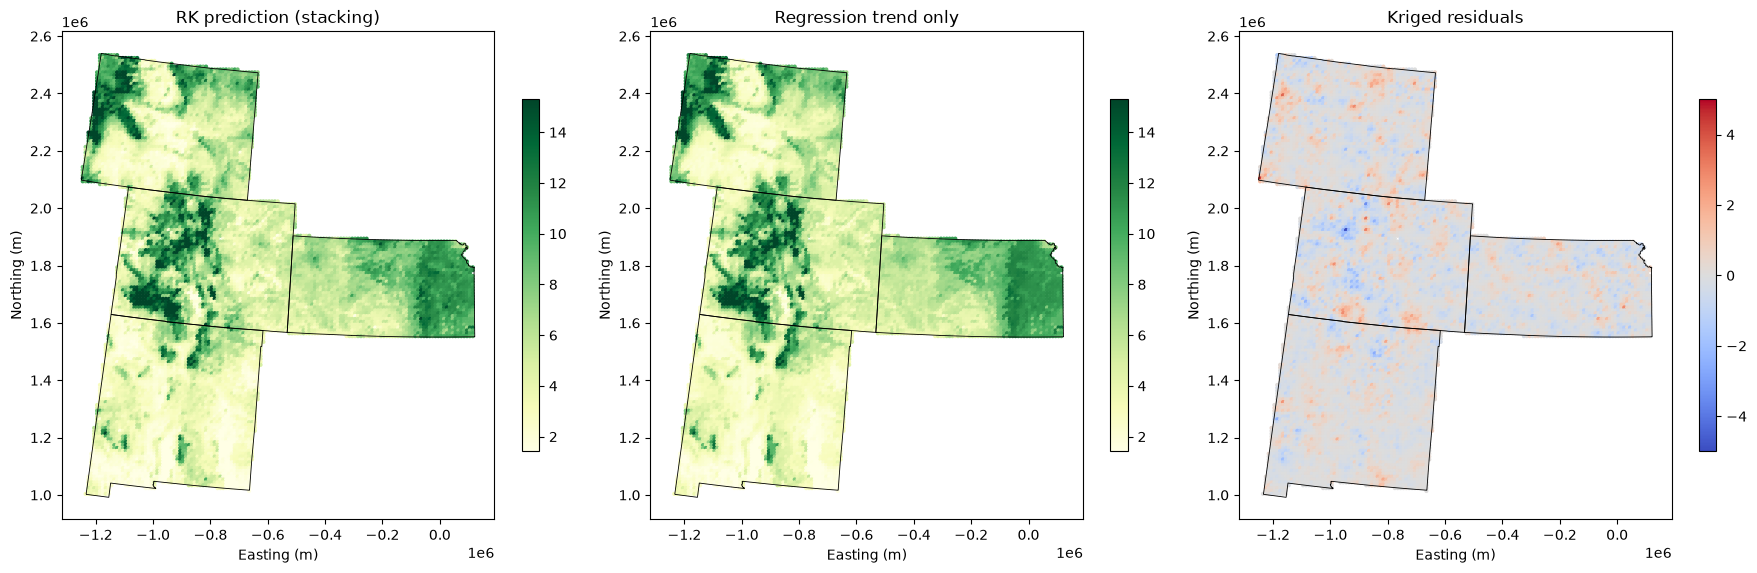

In [21]:
vmin = np.nanpercentile(grid_df["SOC_best"], 2)
vmax = np.nanpercentile(grid_df["SOC_best"], 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"RK prediction ({best_name})", vmin, vmax)
map_points(axes[1], "reg_best", "YlGn", "Regression trend only", vmin, vmax)
map_points(axes[2], "resid_best", "coolwarm", "Kriged residuals",
           vmin=-5, vmax=5)
plt.tight_layout()
plt.show()


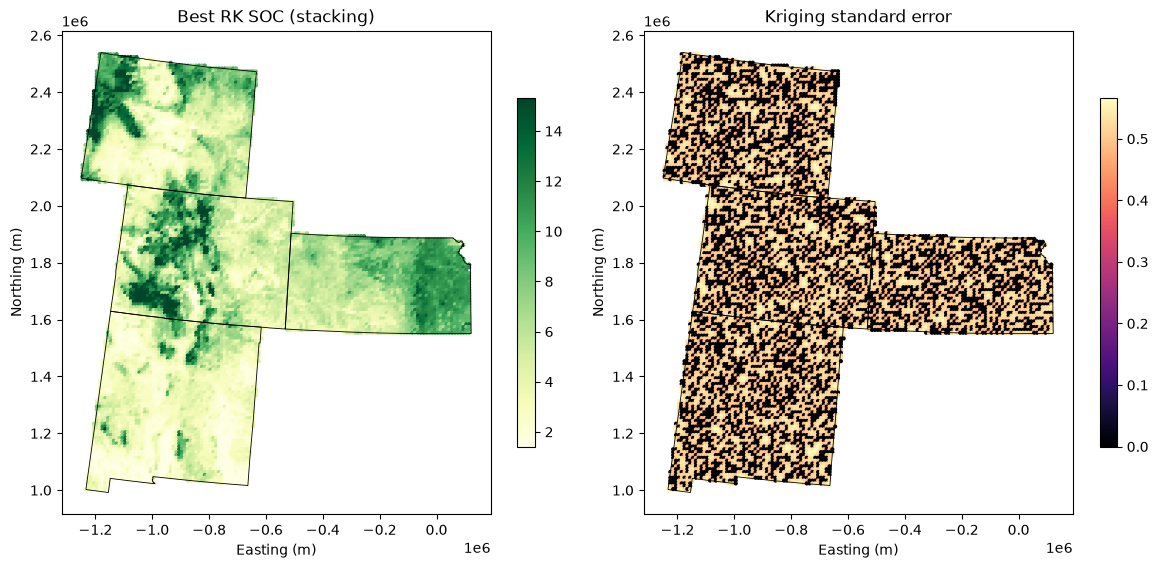

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"Best RK SOC ({best_name})", vmin, vmax)
map_points(axes[1], "SOC_best_se", "magma", "Kriging standard error")
plt.tight_layout()
plt.show()


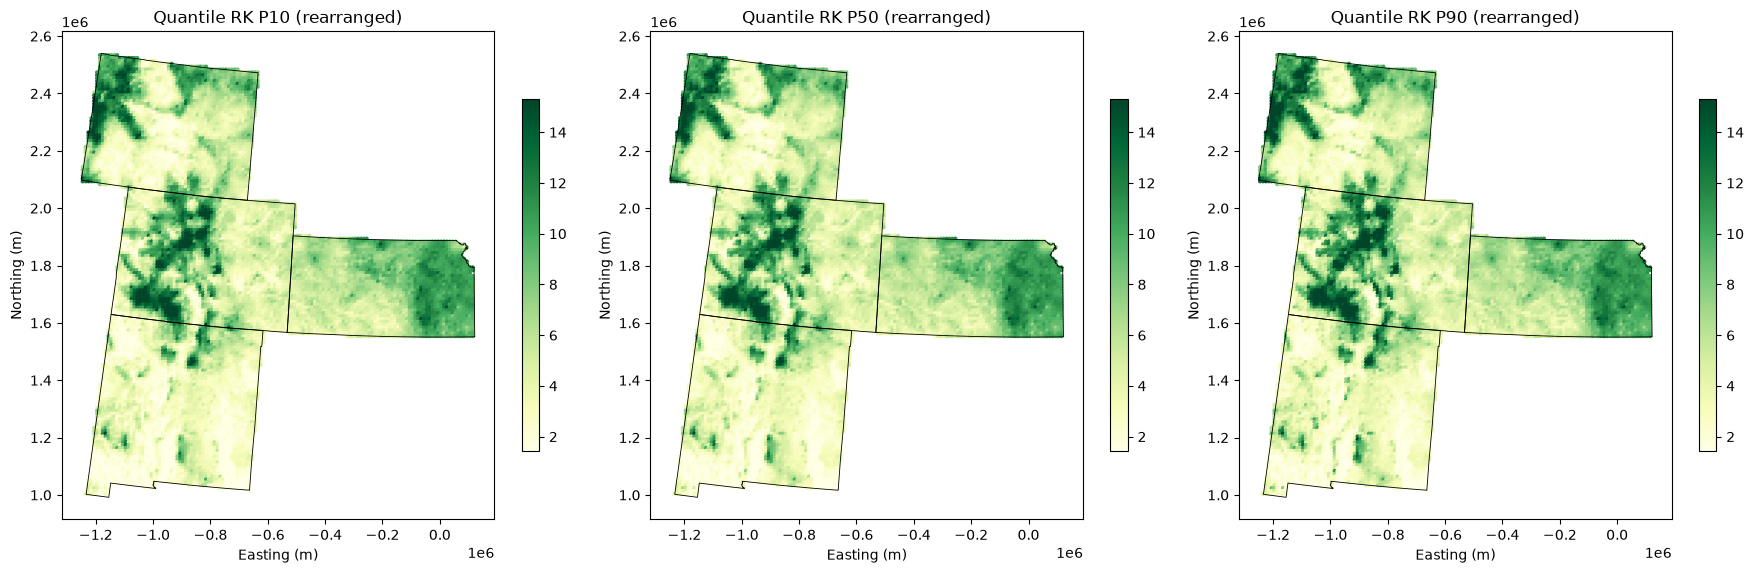

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
map_points(axes[0], "SOC_P10", "YlGn", "Quantile RK P10 (rearranged)", vmin, vmax)
map_points(axes[1], "SOC_P50", "YlGn", "Quantile RK P50 (rearranged)", vmin, vmax)
map_points(axes[2], "SOC_P90", "YlGn", "Quantile RK P90 (rearranged)", vmin, vmax)
plt.tight_layout()
plt.show()


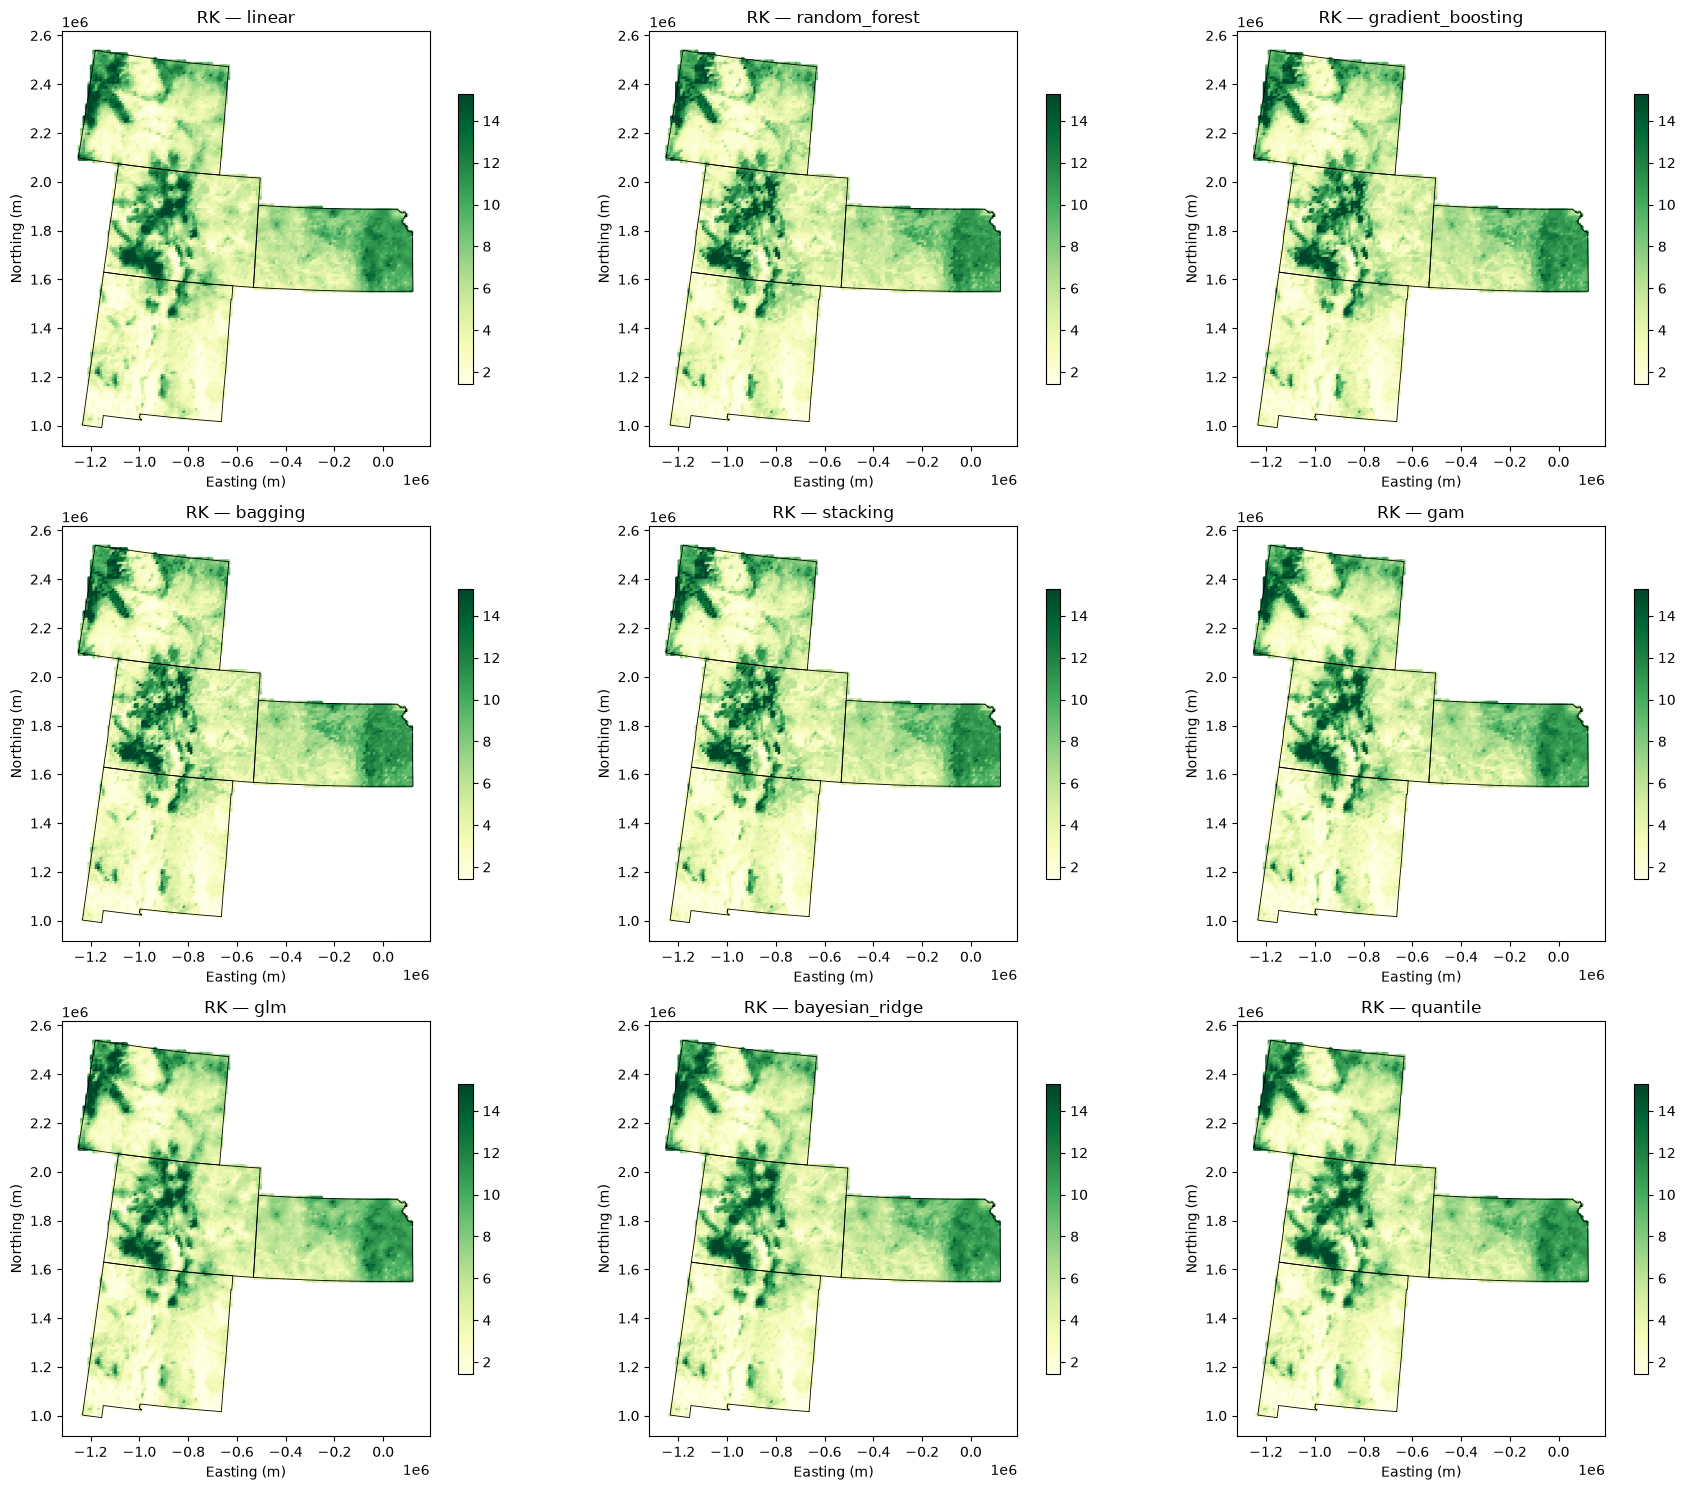

In [24]:
# Side-by-side grid predictions for every trend model
n = len(model_names)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, model_names):
    map_points(ax, f"SOC_{name}", "YlGn", f"RK — {name}", vmin, vmax)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


***
## 14. CPU vs GPU RK Timing

Section 3.1 showed how to *select* a backend. Here we measure how long **residual ordinary kriging** takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) for prefixes of the Great Plains SOC survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The GPU-accelerated steps are the $n \times n$ residual covariance among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** OK system. The sklearn trend (`regressor='linear'`) is cheap and stays on CPU. Residual variograms are fitted once per prefix (spherical model, same `maxlag` / `n_lags` as the rest of this notebook) and are **not** included in the RK times.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the OK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `RegressionKriging.fit` + `predict(..., return_std=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of RK fit + predict)
GP SOC     : 5000 samples from data/gp_data_5000.csv
Trend      : linear (sklearn stays on CPU; residual OK uses use_gpu)
GP n_pred  : 500 grid locations

 dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
GP (SOC)      500     500      47.4      11.7   4.05×   True
GP (SOC)     1000     500     160.4      27.6   5.81×   True
GP (SOC)     2000     500     367.5      62.6   5.87×   True
GP (SOC)     4000     500    1324.9     213.6   6.20×   True
GP (SOC)     5000     500    2072.3     372.3   5.57×   True


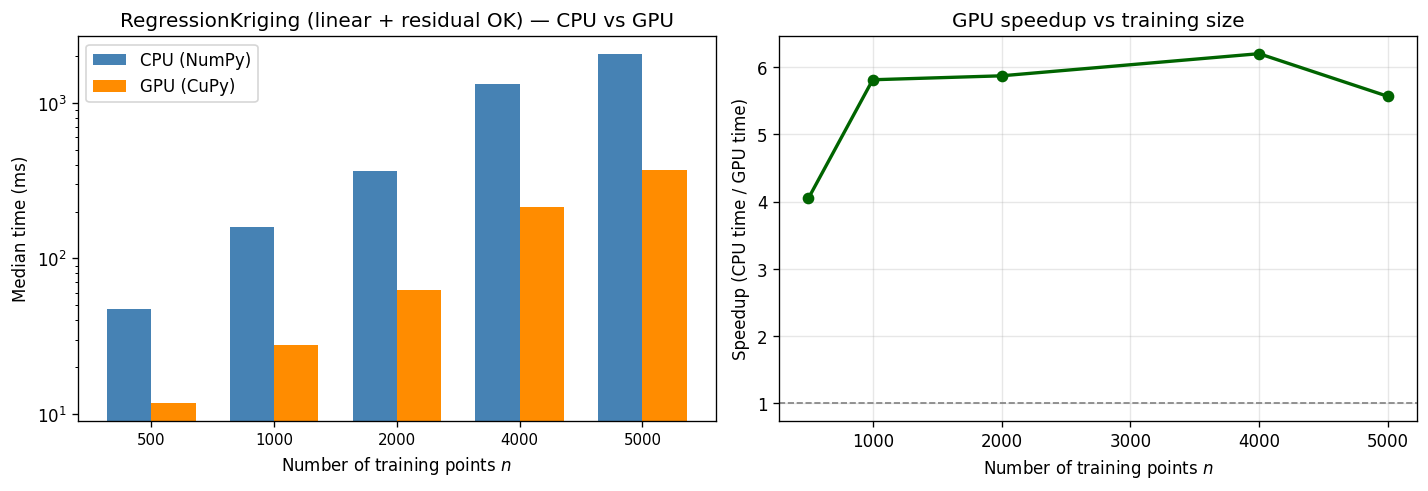

In [22]:
import time
from sklearn.linear_model import LinearRegression

N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]
rng_bench = np.random.default_rng(42)

pred_idx = rng_bench.choice(len(X_grid), size=N_PRED_GP, replace=False)
X_pred_b = X_grid[pred_idx]
xy_pred_b = coords_grid[pred_idx]


def _residual_variogram(X_tr, y_tr, xy_tr):
    lin = LinearRegression().fit(X_tr, y_tr)
    resid = y_tr - lin.predict(X_tr)
    vg_kw = dict(VARIOGRAM_KWARGS)
    vg_kw.pop("use_gpu", None)
    return Variogram(
        np.asarray(xy_tr, dtype=float),
        np.asarray(resid, dtype=float),
        model="spherical",
        estimator="matheron",
        use_gpu=False,
        **vg_kw,
    ).fit()


def _time_rk(X_tr, y_tr, xy_tr, X_pr, xy_pr, vg, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of RegressionKriging.fit + predict(return_std=True)."""
    if warmup:
        k_tr = min(40, len(xy_tr))
        k_pr = min(40, len(xy_pr))
        RegressionKriging(
            regressor="linear", variogram=vg, use_gpu=use_gpu
        ).fit(X_tr[:k_tr], y_tr[:k_tr], xy_tr[:k_tr]).predict(
            X_pr[:k_pr], xy_pr[:k_pr], return_std=True
        )
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        rk_m = RegressionKriging(
            regressor="linear", variogram=vg, use_gpu=use_gpu
        ).fit(X_tr, y_tr, xy_tr)
        last = rk_m.predict(X_pr, xy_pr, return_std=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of RK fit + predict)")
print(f"GP SOC     : {len(y)} samples from data/gp_data_5000.csv")
print(f"Trend      : linear (sklearn stays on CPU; residual OK uses use_gpu)")
print(f"GP n_pred  : {N_PRED_GP} grid locations")
print()

rows = []
for n in GP_SIZES:
    X_tr, y_tr, xy_tr = X[:n], y[:n], coords[:n]
    vg = _residual_variogram(X_tr, y_tr, xy_tr)

    cpu_t, pred_cpu = _time_rk(X_tr, y_tr, xy_tr, X_pred_b, xy_pred_b, vg, use_gpu=False)
    row = {
        "dataset": "GP (SOC)",
        "n_train": n,
        "n_pred": N_PRED_GP,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_rk(X_tr, y_tr, xy_tr, X_pred_b, xy_pred_b, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel("Number of training points $n$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("RegressionKriging (linear + residual OK) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and residual-kriging standard errors from the two backends should **match** (`match = True`). The sklearn linear trend is the same on both runs; the GPU speedup comes from the residual OK covariance build and solve. On the Great Plains SOC prefixes the $O(n^2)$ covariance and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 15. Summary and Conclusions

This notebook applied **regression kriging** to Great Plains **soil organic carbon**, combining a covariate-driven trend with ordinary kriging of residuals (`pygstat.RegressionKriging`).

- **Data.** 5,000 samples (`gp_data_5000.csv`) and a 10 km grid (`gp_grid.csv`). **NLCD** is a **categorical** land-cover class, dummy-encoded with `OneHotEncoder(drop="first")` rather than treated as an ordinal score.
- **Trend models.** Every shortcut in `ENSEMBLE_REGRESSORS` (`linear`, `random_forest`, `gradient_boosting`, `bagging`, `stacking`) and `STATISTICAL_REGRESSORS` (`gam` / `GAMRegressor`, `glm`, `bayesian_ridge`, `quantile`) was fitted as an RK model.
- **Validation.** Models were ranked with **5-fold CV** on the training set and a **NLCD-stratified 30% hold-out**. Tree ensembles and the GAM typically improve on a plain linear trend because SOC–covariate relationships are nonlinear; residual kriging then adds local spatial structure that regression alone misses.
- **Quantiles.** Independently kriged P10 / P50 / P90 surfaces **cross**. `enforce_quantile_monotonicity` restores order at every location without changing the set of predicted values.
- **Mapping.** SOC, the regression trend, kriged residuals, kriging standard error, and rearranged quantile surfaces were predicted on `gp_grid.csv`.
- **CPU / GPU.** Residual ordinary kriging (`use_gpu=USE_GPU`) was timed on prefixes of `gp_data_5000.csv`. The sklearn trend stays on CPU; the $O(n^2)$ covariance and $O(n^3)$ OK solve are the GPU-accelerated steps.

Regression kriging remains a practical default for digital soil mapping: a flexible trend for what the covariates can explain, and geostatistics for what they cannot.


***
## 16. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Hengl, T., Heuvelink, G.B.M. & Stein, A. (2004). A generic framework for spatial prediction of soil variables based on regression-kriging. *Geoderma* 120, 75–93. | RK as used in digital soil mapping |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences* 33, 1301–1315. | Practical RK workflow |
| Odeh, I.O.A., McBratney, A.B. & Chittleborough, D.J. (1995). Further results on prediction of soil properties from terrain attributes: heterotopic cokriging and regression-kriging. *Geoderma* 67, 215–226. | Early RK for soil properties |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | SK with a varying local mean |
| Chernozhukov, V., Fernández-Val, I. & Galichon, A. (2010). Quantile and probability curves without crossing. *Econometrica* 78, 1093–1125. | Rearrangement / quantile monotonicity |

### In this library

| Object | Role |
|--------|------|
| `pygstat.RegressionKriging` | Trend + ordinary kriging of residuals (`use_gpu`) |
| `ENSEMBLE_REGRESSORS` | `'linear'`, `'random_forest'`, `'gradient_boosting'`, `'bagging'`, `'stacking'` |
| `STATISTICAL_REGRESSORS` | `'gam'`, `'glm'`, `'bayesian_ridge'`, `'quantile'` |
| `GAMRegressor` | scikit-learn wrapper around pyGAM (the `'gam'` shortcut) |
| `enforce_quantile_monotonicity` | Sort independently fitted quantile surfaces pointwise |
| `KFoldCV_RK` / `LOOCV_RK` | Spatial CV that refits both the trend and residual kriging |
| `pygstat.Variogram` | Residual (and exploratory) variogram |
